In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from skimage.exposure import equalize_adapthist
from skimage.filters import gaussian as sk_gaussian
from scipy.ndimage import uniform_filter, gaussian_filter
from scipy.stats import pearsonr
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from tqdm import tqdm
from pathlib import Path
import warnings
import torch
import torch.nn as nn

warnings.filterwarnings('ignore')



speckles = np.load('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/speckle.npy')

In [2]:
def myfft2(A):
    return np.fft.fftshift(np.fft.fft2(np.fft.fftshift(A)))


def gabor_THIS(A, GM1, GM2):
    """
    Gabor encoder — direct replacement for Baurzhan's vort_THIS.

    Takes a batch of images and applies:
    1. Phase encode: exp(i * image * pi/2)  — same as Baurzhan
    2. Multiply by Lens
    3. FFT (myfft2)
    4. Multiply by Gabor mask in Fourier plane — replaces vortex mask
    5. Take magnitude
    6. Normalise to [-1, 1]
    7. Concatenate dual channel

    Can be applied to both:
    - Gaussian beam speckles (Method 1 training)
    - Real chest X-ray images (Method 2 training + inference)

    Parameters
    ----------
    A   : (N, H, W) float32 — batch of images in [0,1]
    GM1 : (H, W) float64   — Gabor Fourier mask channel 1
    GM2 : (H, W) float64   — Gabor Fourier mask channel 2

    Returns
    -------
    out : (N, H, W*2) float32 — dual channel Gabor encoded, normalised to [-1,1]
    """
    length = A.shape[0]
    out    = np.zeros((length, A.shape[1], A.shape[2] * 2), dtype=np.float32)

    for i in range(length):
        phase = np.exp(1j * A[i].astype(np.float64) * np.pi / 2)

        A1 = np.abs(myfft2(phase * Lens) * GM1).astype(np.float32)
        A2 = np.abs(myfft2(phase * Lens) * GM2).astype(np.float32)

        A1 = (A1 - np.amin(A1)) / (np.amax(A1 - np.amin(A1)) + 1e-8) * 2 - 1
        A2 = (A2 - np.amin(A2)) / (np.amax(A2 - np.amin(A2)) + 1e-8) * 2 - 1

        out[i] = np.hstack((A1, A2))

    return out



def make_isotropic_gabor_mask(DIM=64, omega_0=0.07, sigma_f=0.3):
    """
    Isotropic (orientation-independent) bandpass ring in the Fourier plane.
    Passes energy at radius ~omega_0 regardless of direction — appropriate
    for features with no preferred orientation (e.g. diffuse haze/texture).
    """
    sigma_f_abs = sigma_f * omega_0

    freqs = np.fft.fftshift(np.fft.fftfreq(DIM))
    U, V = np.meshgrid(freqs, freqs)
    R = np.sqrt(U**2 + V**2)

    mask = np.exp(-((R - omega_0)**2) / (2 * sigma_f_abs**2))
    return (mask / mask.max()).astype(np.float64)



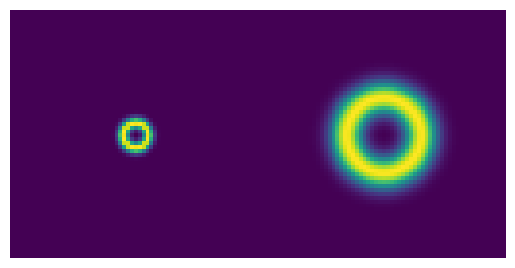

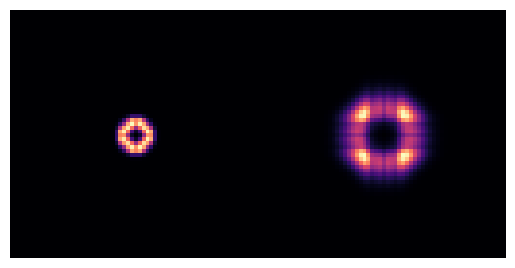

In [3]:
# Coordinates + Lens
DIM     = 64
xmax    = 10
dx      = 2 * xmax / DIM

x       = np.linspace(-xmax, xmax - dx, DIM)
X, Y    = np.meshgrid(x, x)
R2      = X**2 + Y**2
T       = np.arctan2(Y, X)

flambda = 80
Lens    = np.exp(-1j * R2 / (flambda / 10))


# Gabor Mask
GM1 = make_isotropic_gabor_mask(DIM=DIM, omega_0=0.05)
GM2 = make_isotropic_gabor_mask(DIM=DIM, omega_0=0.15)

plt.imshow(np.hstack((GM1, GM2)), cmap='viridis')
plt.axis('off')
plt.show()

encoded_speckles = gabor_THIS(speckles, GM1, GM2)

plt.imshow(encoded_speckles[2], cmap='magma')
plt.axis('off')
plt.show()

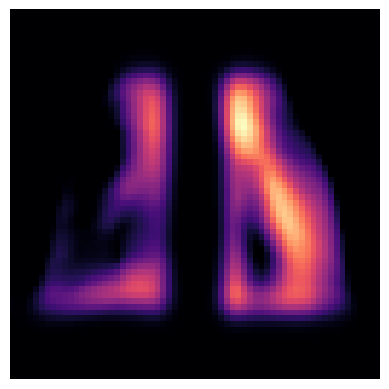

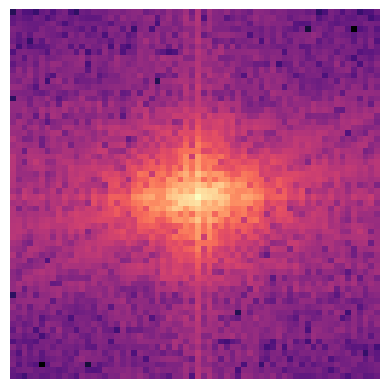

In [17]:
plt.imshow(speckles[0], cmap='magma')
plt.axis('off')
plt.show()

plt.imshow(np.log(np.abs(myfft2(speckles[0]))) + 1e-8, cmap='magma')
plt.axis('off')
plt.show()

In [11]:
# Define model
class base_model(nn.Module):
    def __init__(self, dim, n_channels=2):
        super().__init__()
        self.fc = nn.Linear(n_channels * dim**2, dim**2, bias=False) # Linear Activation
        self.criterion = nn.MSELoss()
        self.optimizer = torch.optim.Adam(  self.parameters(), lr=1e-4)

    def forward(self, x):
        return self.fc(x)

DIM = 64
model = base_model(DIM)



# Input data prep
x_train = encoded_speckles.reshape(len(encoded_speckles), -1).astype(np.float32)
y_train = speckles.reshape(len(speckles), -1).astype(np.float32)

x_train = torch.tensor(x_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)

# Training Loop
dataset = torch.utils.data.TensorDataset(x_train, y_train)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=16, shuffle=True)

In [12]:
epochs = 500
model.train()
loss_history = []

for epoch in range(epochs):
    total_loss = 0.0
    for batch_x, batch_y in dataloader:
        model.optimizer.zero_grad()
        preds = model(batch_x)
        loss = model.criterion(preds, batch_y)
        loss.backward()
        model.optimizer.step()
        total_loss += loss.item()

    avg_loss = total_loss / len(dataloader)
    loss_history.append(avg_loss)

    print(f'{epoch}/{epochs}, loss={avg_loss:.6f}')


destination = 'mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/speckle_gabor_weights.pth'
torch.save(model.state_dict(), destination)


0/500, loss=0.012761
1/500, loss=0.000369
2/500, loss=0.000298
3/500, loss=0.000230
4/500, loss=0.000197
5/500, loss=0.000166
6/500, loss=0.000155
7/500, loss=0.000188
8/500, loss=0.000245
9/500, loss=0.000289
10/500, loss=0.000285
11/500, loss=0.000364
12/500, loss=0.000435
13/500, loss=0.000420
14/500, loss=0.000453
15/500, loss=0.000429
16/500, loss=0.000484
17/500, loss=0.000475
18/500, loss=0.000444
19/500, loss=0.000467
20/500, loss=0.000472
21/500, loss=0.000461
22/500, loss=0.000470
23/500, loss=0.000442
24/500, loss=0.000483
25/500, loss=0.000489
26/500, loss=0.000428
27/500, loss=0.000446
28/500, loss=0.000456
29/500, loss=0.000483
30/500, loss=0.000448
31/500, loss=0.000454
32/500, loss=0.000465
33/500, loss=0.000439
34/500, loss=0.000449
35/500, loss=0.000477
36/500, loss=0.000463
37/500, loss=0.000425
38/500, loss=0.000487
39/500, loss=0.000409
40/500, loss=0.000488
41/500, loss=0.000422
42/500, loss=0.000483
43/500, loss=0.000448
44/500, loss=0.000458
45/500, loss=0.00044

KeyboardInterrupt: 

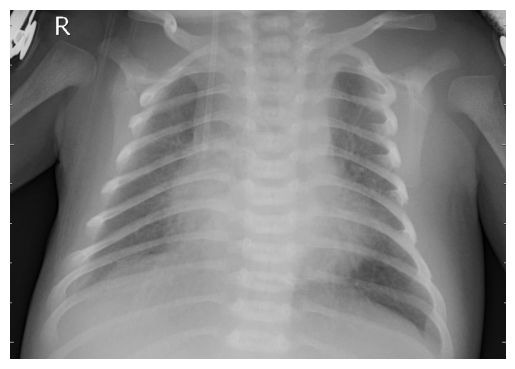

In [35]:
import cv2
import matplotlib.pyplot as plt

img = cv2.imread('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/test/PNEUMONIA/person86_bacteria_429.jpeg')
#img = cv2.imread('/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/test/NORMAL/IM-0027-0001.jpeg')

plt.imshow(img)
plt.axis('off')
plt.show()

In [36]:
DIM         = 64
NUM_CLASSES = 2
TRAIN_DIR   = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/train'
TEST_DIR    = '/mnt/c/Users/Jet/Documents/PhD Data/Machine Vision/chest_xray/test'

def apply_smooth_region_filter(image, window=9):
    mean_sq        = uniform_filter(image**2, size=window)
    sq_mean        = uniform_filter(image,    size=window)**2
    local_std      = np.sqrt(np.clip(mean_sq - sq_mean, 0, None)).astype(np.float32)
    s_rng          = local_std.max() - local_std.min()
    local_std_norm = (local_std - local_std.min()) / (s_rng + 1e-8)
    smooth_mask    = gaussian_filter(1.0 - local_std_norm, sigma=1.0)
    filtered       = image * smooth_mask
    f_rng          = filtered.max() - filtered.min()
    return ((filtered - filtered.min()) / (f_rng + 1e-8)).astype(np.float32)


def norm_batch(X):
    mn = X.min(axis=(1,2), keepdims=True)
    mx = X.max(axis=(1,2), keepdims=True)
    return (X - mn) / (mx - mn + 1e-8)


def to_gray(images_rgb, dim=DIM):
    out = np.empty((len(images_rgb), dim, dim), dtype=np.float32)
    for i, img in enumerate(images_rgb):
        gray   = cv2.cvtColor(img.astype(np.uint8), cv2.COLOR_RGB2GRAY)
        out[i] = gray / 255.0
    return out


def preprocess_xray(img, dim=DIM, window=9):
    img  = equalize_adapthist(img, clip_limit=0.03).astype(np.float32)
    h, w = img.shape
    pad_h = int(h * 0.10); pad_w = int(w * 0.08)
    img   = img[pad_h:h-pad_h, pad_w:w-pad_w]
    img   = cv2.resize(img, (dim, dim), interpolation=cv2.INTER_AREA)
    img   = sk_gaussian(img, sigma=0.5).astype(np.float32)
    if img.max() > 1e-8:
        img = img / img.max()
    img   = apply_smooth_region_filter(img, window=window)
    return img

Train: 100%|██████████| 1/1 [00:00<00:00, 161.72it/s]


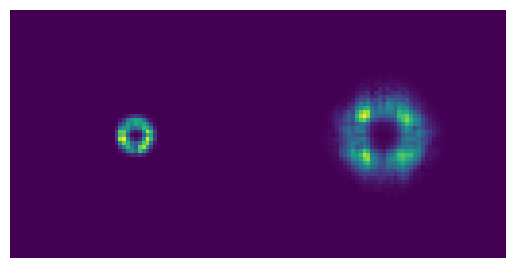

In [37]:
img = cv2.resize(img, (64, 64))
img = np.expand_dims(img, axis=0)
img = to_gray(img)

img_processed = np.zeros((len(img), DIM, DIM), dtype=np.float32)

for i in tqdm(range(len(img)), desc='Train'):
    img_processed[i] = preprocess_xray(img[i])

img = img_processed
del img_processed

img_transformed = gabor_THIS(img, GM1, GM2)
img = np.squeeze(img_transformed, axis=0)

plt.imshow(img)
plt.axis('off')
plt.show()

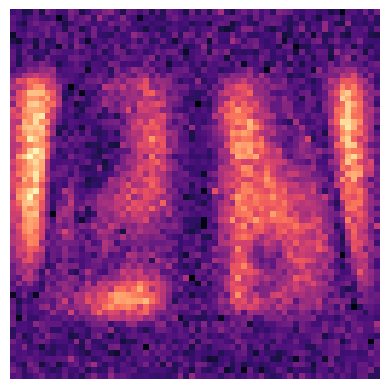

In [38]:
img_flat = torch.tensor(img.flatten(), dtype=torch.float32).unsqueeze(0)

model.eval()

with torch.no_grad():
    output = model(img_flat)

output_img = output.squeeze(0).numpy().reshape(DIM, DIM)

plt.imshow(output_img, cmap='magma')
plt.axis('off')
plt.show()